In [3]:
import pandas as pd
import numpy as np

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

import joblib

In [5]:
df = pd.read_csv("../data/german_credit_data.csv")

In [6]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 115.1 KB


In [8]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [9]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [10]:
df.fillna(df.mode().iloc[0], inplace=True)

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,little,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,little,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad
...,...,...,...,...,...,...,...,...,...,...
995,31,female,1,own,little,little,1736,12,furniture/equipment,good
996,40,male,3,own,little,little,3857,30,car,good
997,38,male,2,own,little,little,804,12,radio/TV,good
998,23,male,2,free,little,little,1845,45,radio/TV,bad


In [11]:
df["Risk"].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [12]:
df["Risk"] = df["Risk"].map({
    "good": 1,
    "bad": 0
})

In [13]:
df["Debt_Income_Ratio"] = df["Credit amount"] / (df["Age"] + 1)

In [14]:
df["Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,25,35,50,100],
    labels=["Young","Adult","Middle","Senior"]
)

In [15]:
le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col])

/var/folders/q4/tzb2rm8s5yqf3jjrjnl6q_km0000gn/T/ipykernel_7640/2852344203.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include="object").columns:


In [16]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object' or str(df[col].dtype) == 'category':
        df[col] = le.fit_transform(df[col])

In [19]:
X = df.drop("Risk", axis=1)
y = df["Risk"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [21]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [22]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train, y_train = smote.fit_resample(X_train, y_train)

In [23]:
#regression 
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [24]:
dt = DecisionTreeClassifier(max_depth=5)

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

In [25]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

In [26]:
def evaluate(y_true, y_pred):

    print("Accuracy:",
          accuracy_score(y_true, y_pred))

    print("Precision:",
          precision_score(y_true, y_pred))

    print("Recall:",
          recall_score(y_true, y_pred))

    print("F1 Score:",
          f1_score(y_true, y_pred))

In [27]:
print("LOGISTIC REGRESSION")
evaluate(y_test, lr_pred)

print("\nDECISION TREE")
evaluate(y_test, dt_pred)

print("\nRANDOM FOREST")
evaluate(y_test, rf_pred)

LOGISTIC REGRESSION
Accuracy: 0.675
Precision: 0.8151260504201681
Recall: 0.6928571428571428
F1 Score: 0.749034749034749

DECISION TREE
Accuracy: 0.585
Precision: 0.7878787878787878
Recall: 0.5571428571428572
F1 Score: 0.6527196652719666

RANDOM FOREST
Accuracy: 0.67
Precision: 0.743421052631579
Recall: 0.8071428571428572
F1 Score: 0.773972602739726


In [28]:
rf_probs = rf.predict_proba(X_test)[:,1]

roc_auc_score(y_test, rf_probs)

0.645952380952381

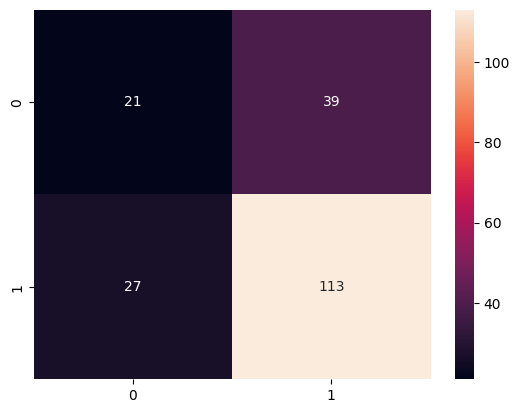

In [29]:
cm = confusion_matrix(y_test, rf_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [30]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance.head(10))

              Feature  Importance
7            Duration    0.177082
6       Credit amount    0.141454
9   Debt_Income_Ratio    0.140957
0                 Age    0.138703
8             Purpose    0.115008
4     Saving accounts    0.064095
2                 Job    0.051154
10          Age_Group    0.047593
5    Checking account    0.046870
3             Housing    0.043765


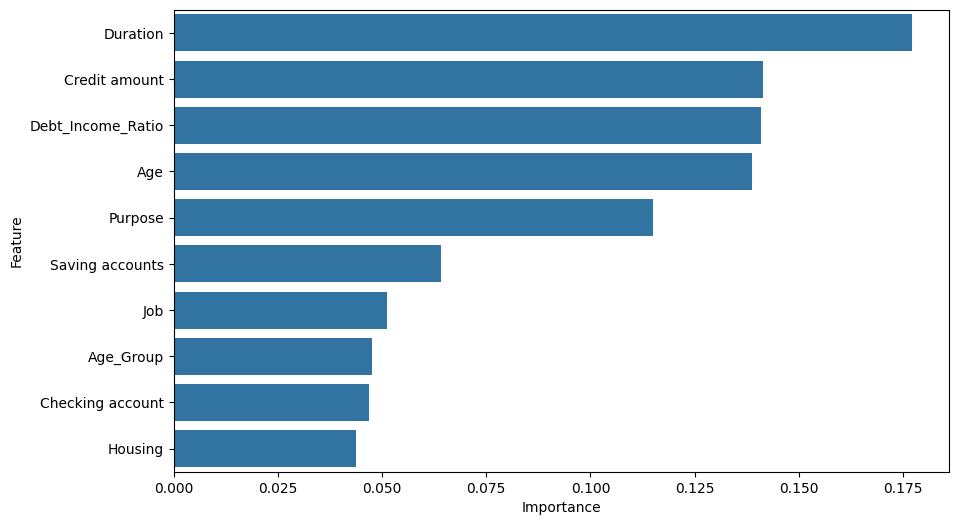

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.show()

In [32]:
from sklearn.model_selection import GridSearchCV

In [36]:
params = {
    'n_estimators': [100,200],
    'max_depth': [5,10,15],
    'min_samples_split': [2,5]
}

In [37]:
grid = GridSearchCV(
    RandomForestClassifier(),
    params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'f1'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"verbose verbose: int, default=0Controls the verbosi

In [39]:
best_model = grid.best_estimator_

In [40]:
joblib.dump(best_model, "../models/credit_model.pkl")
joblib.dump(scaler, "../models/scaler.pkl")

['../models/scaler.pkl']

In [41]:
!pip install xgboost


In [42]:
from xgboost import XGBClassifier

In [43]:
xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

xgb.fit(X_train, y_train)

,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None
,feature_types,None


In [44]:
xgb_pred = xgb.predict(X_test)

In [45]:
xgb_pred = xgb.predict(X_test)

In [46]:
print("Accuracy:",
      accuracy_score(y_test, xgb_pred))

print("Precision:",
      precision_score(y_test, xgb_pred))

print("Recall:",
      recall_score(y_test, xgb_pred))

print("F1 Score:",
      f1_score(y_test, xgb_pred))

Accuracy: 0.665
Precision: 0.738562091503268
Recall: 0.8071428571428572
F1 Score: 0.7713310580204779


In [47]:
xgb_probs = xgb.predict_proba(X_test)[:,1]

print(
    roc_auc_score(y_test, xgb_probs)
)

0.6321428571428572


In [48]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": xgb.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
4,Saving accounts,0.157651
7,Duration,0.126554
1,Sex,0.104246
8,Purpose,0.095924
2,Job,0.083172
3,Housing,0.079652
5,Checking account,0.078475
0,Age,0.077193
10,Age_Group,0.072519
9,Debt_Income_Ratio,0.065881


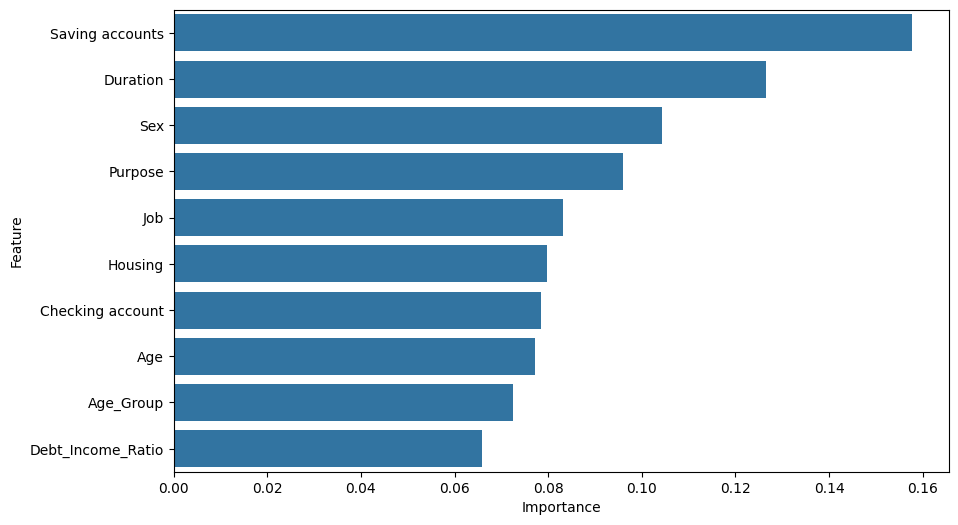

In [49]:
plt.figure(figsize=(10,6))

sns.barplot(
    x="Importance",
    y="Feature",
    data=importance.head(10)
)

plt.show()

In [50]:
import joblib

joblib.dump(xgb, "credit_xgboost_model.pkl")

['credit_xgboost_model.pkl']

In [51]:
import joblib

joblib.dump(best_model, "credit_model.pkl")
joblib.dump(scaler, "scaler.pkl")

['scaler.pkl']

In [52]:
print(X.columns)
print(len(X.columns))


Index(['Age', 'Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account',
       'Credit amount', 'Duration', 'Purpose', 'Debt_Income_Ratio',
       'Age_Group'],
      dtype='str')
11


In [53]:
print(features.shape)

NameError: name 'features' is not defined